## **Flowmap City**

https://docs.flowmap.city/docs/create-new-project/prepare-data

OD pairs broken down filterable by the hourly temporal space as well as the given routes.

If I map out each currently used stop circa Oct25 and Feb26 I should be able to make a doc with all these used stops. Then from there have the long and lat at each one. The ID can probably be the ID we used in the department, or jsut arbitrarily assign it. Either way, mapping these to the transit lab OD data will be important to be consistent with it, likely can just use a simple dictionary lookup for this.

Data needs to be cleaned up into 2 datasets:

1) locations -> this will be generally static I think I can just use the same one for everything probably

```
id,name,lat,lng/n
1,New York,40.7128,-74.0060
2,Los Angeles,34.0522,-118.2437
3,Chicago,41.8781,-87.6298
4,Houston,29.7604,-95.3698

```

2) flows data -> this will be the expanded origin and destination pairs with count

```
origin,dest,count
1,2,100
1,3,50
1,4,25
2,1,75
2,3,25
2,4,50
```


In [1]:
import pandas as pd
import numpy as np

# import the od pairs
DATA_PATH = 'K:/AP/TTM/Data/transportation-planning/data/transit-lab/od-pairs/'

In [2]:
# parse the pattern stops file from oct25 in this test case to get the long/lat coords 
pattern_stops = pd.read_csv('./data/pattern-stops/2025082420251018Sch-PatternStops_oct2025.csv', header=None)

# drop fluff
pattern_stops = pattern_stops.drop(
    columns=[2,3,4,5,6,7,8,11,12,13,14,15,18] + list(range(20, pattern_stops.shape[1]))
)
# clean up column names 
pattern_stops.columns = ['route_id', 'route_name', 'stop_id', 'stop_name', 'lat', 'long', 'direction']
pattern_stops

pattern_stops.head()

,route_id,route_name,stop_id,stop_name,lat,long,direction
0,BE,Buckeye Express,75,BUCKEYE LOT LOOP,-83.030646,40.015933,IB
1,BE,Buckeye Express,20,MID WEST CAMPUS (EB),-83.026541,40.004251,IB
2,BE,Buckeye Express,21,ST. JOHN EAST BOUND,-83.020744,40.004048,IB
3,BE,Buckeye Express,57,KNOWLTON HALL,-83.016142,40.003979,IB
4,BE,Buckeye Express,58,FONTANA LAB,-83.013197,40.003839,IB


In [3]:
# for this use case will use only CC routes
cc_locations = pattern_stops[pattern_stops['route_id'] == 'CC']
cc_locations.drop_duplicates(inplace=True)
# NOTE: This contains the IB/OB directions now
# print(cc_locations.shape)
# cc_locations.head(50)

# swap lat and long locations
cc_locations[['lat', 'long']] = cc_locations[['long', 'lat']]

# getting rid of the IB/OB directions to get only a list of each and every stop
cc_locations = cc_locations.drop(columns=['direction'])
cc_locations.drop_duplicates(inplace=True)
cc_locations.head(3)

,route_id,route_name,stop_id,stop_name,lat,long
22,CC,Campus Connector,501,MOUNT HALL LOOP,40.003715,-83.036691
23,CC,Campus Connector,94,CARMACK 5 + STOP 1,40.002781,-83.042454
24,CC,Campus Connector,95,CARMACK 5 + STOP 2,40.002898,-83.041104


In [4]:
# parse to get the stripped down location data for cc
cc_locations_final = cc_locations.copy()
cc_locations_final.drop(columns=['route_id', 'route_name'], inplace=True)

# save to test location as csv w/o index
# cc_locations_final.to_csv('./data/flowmap-city-testcase/cc_locations.csv', index=False)
cc_locations_final.head(25)

,stop_id,stop_name,lat,long
22,501,MOUNT HALL LOOP,40.003715,-83.036691
23,94,CARMACK 5 + STOP 1,40.002781,-83.042454
24,95,CARMACK 5 + STOP 2,40.002898,-83.041104
25,15,AG RESEARCH CENTER,39.998613,-83.042733
26,18,KINNEAR ROAD LOT,39.997554,-83.038395
27,14,BLANKENSHIP HALL,40.003182,-83.033337
28,20,MID WEST CAMPUS (EB),40.004251,-83.026541
29,21,ST. JOHN EAST BOUND,40.004048,-83.020744
30,57,KNOWLTON HALL,40.003979,-83.016142
31,58,FONTANA LAB,40.003839,-83.013197


cc_locations now ready for flowmap city

---

### **Pull and Clean Origin Destination Pairs from Transit Lab Excel Sheets**

Loading and parsing data...
Processing route: OD flows inferred from APC data for BE October 2025_2025-10-01_2025-10-31...
Processing route: OD flows inferred from APC data for CC October 2025_2025-10-01_2025-10-31...
Processing route: OD flows inferred from APC data for CLS October 2025_2025-10-01_2025-10-31...
Processing route: OD flows inferred from APC data for ER October 2025_2025-10-01_2025-10-31...
Successfully processed 680 unique route-OD combinations.
Generating per-route visualizations...


C:\Users\morgan.1461\AppData\Local\Temp\ipykernel_30108\608157593.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pairs, x='Volume', y='Pair', palette='viridis', ax=axes[0])


Saved visualization for OD flows inferred from APC data for BE October 2025_2025-10-01_2025-10-31 to K:/AP/TTM/Data/transportation-planning/data/transit-lab/od-pairs/Oct 2025/Plots/OD flows inferred from APC data for BE October 2025_2025-10-01_2025-10-31_analysis.png


C:\Users\morgan.1461\AppData\Local\Temp\ipykernel_30108\608157593.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pairs, x='Volume', y='Pair', palette='viridis', ax=axes[0])


ValueError: Index contains duplicate entries, cannot reshape

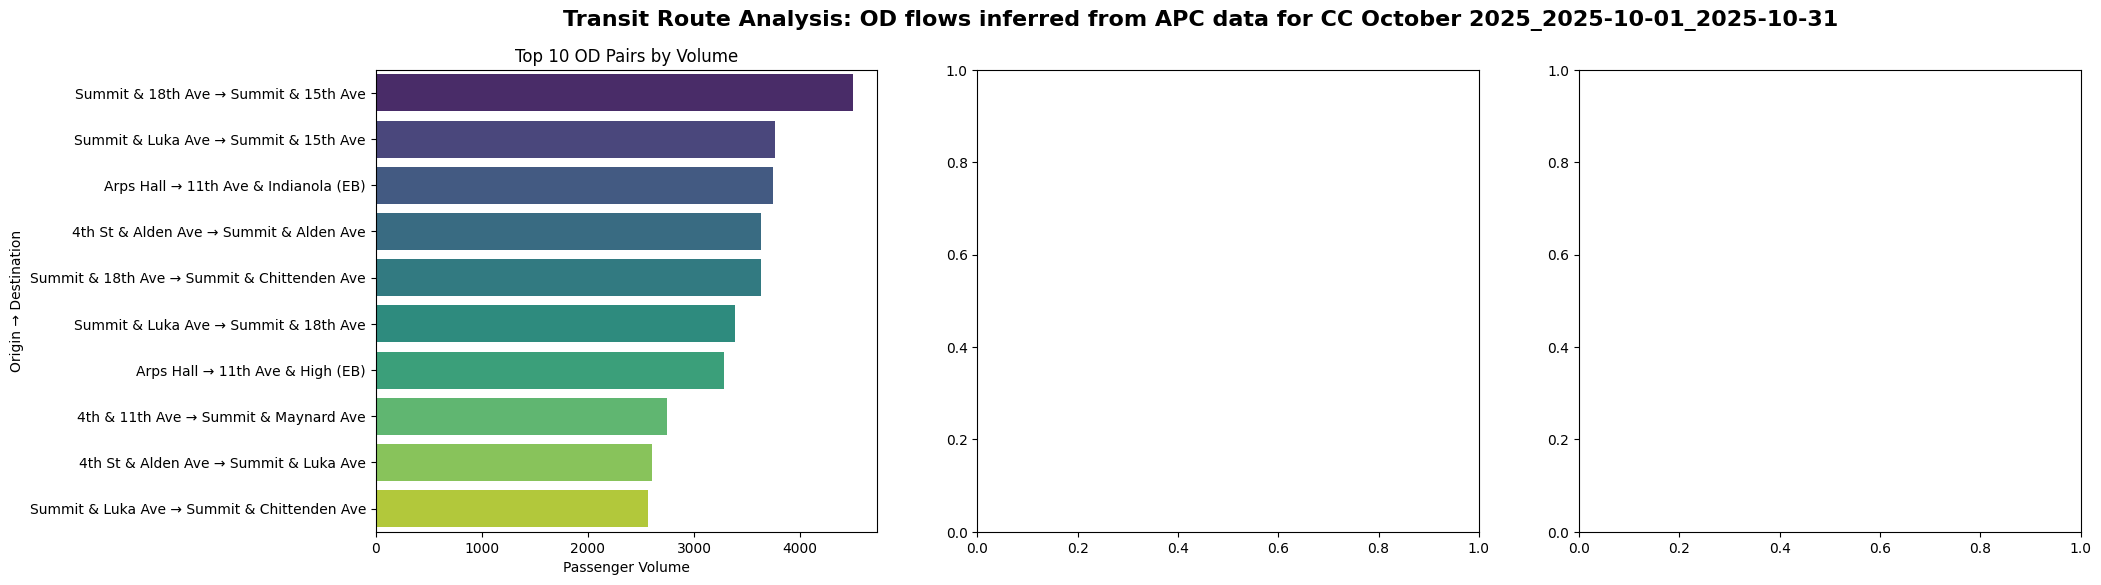

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Define your local data path
DATA_PATH = 'K:/AP/TTM/Data/transportation-planning/data/transit-lab/od-pairs/Oct 2025/Stop level/Hourly/Weekdays/'
# Optional: Directory where per-route plots will be saved (set to None to display inline via plt.show())
OUTPUT_DIR = 'K:/AP/TTM/Data/transportation-planning/data/transit-lab/od-pairs/Oct 2025/Plots/'


def _clean_stop_id(value):
    """Normalizes stop IDs like '24 (1)' or '24.0' to a clean integer-like string."""
    if pd.isna(value):
        return None
    value_str = str(value).strip()
    if not value_str:
        return None
    if 'total' in value_str.lower() or 'sum' in value_str.lower():
        return None
    if value_str.endswith('.0'):
        value_str = value_str[:-2]
    if '(' in value_str:
        value_str = value_str.split('(')[0].strip()
    return value_str if value_str else None


def _is_stop_label(value):
    """True if the cell represents a stop ID like 1, 2, 24 (1), or 24.0."""
    if pd.isna(value):
        return False
    value_str = str(value).strip()
    if not value_str or value_str.lower() in {'origin', 'destination'}:
        return False
    if 'total' in value_str.lower() or 'sum' in value_str.lower():
        return False
    cleaned = _clean_stop_id(value_str)
    if cleaned is None:
        return False
    try:
        float(cleaned)
        return True
    except ValueError:
        return False


def _sort_stop_key(value):
    """Sorts stop IDs numerically even when they include labels like '24 (1)'."""
    value_str = str(value).split('(')[0].strip()
    try:
        return int(float(value_str))
    except (TypeError, ValueError):
        return 999999


def format_od_matrix(df_raw):
    """Reshapes the raw Excel OD matrix into a clean origin-by-destination table."""
    origin_locations = [(r, c) for r in range(df_raw.shape[0]) for c in range(df_raw.shape[1])
                        if str(df_raw.iloc[r, c]).strip().lower() == 'origin']
    if not origin_locations:
        return pd.DataFrame()

    orig_r, orig_c = origin_locations[0]

    dest_locations = [(r, c) for r in range(df_raw.shape[0]) for c in range(df_raw.shape[1])
                      if str(df_raw.iloc[r, c]).strip().lower() == 'destination']
    if not dest_locations:
        return pd.DataFrame()

    dest_r = dest_locations[0][0]
    dest_header_row = dest_r + 1

    # Find the first numeric stop label in the origin row so we don't drop stop 1.
    orig_id_col = None
    for c in range(orig_c, min(orig_c + 25, df_raw.shape[1])):
        val = df_raw.iloc[orig_r, c]
        if _is_stop_label(val):
            orig_id_col = c
            break

    if orig_id_col is None:
        return pd.DataFrame()

    # Find the first numeric stop label in the destination header row so all destination stops are kept.
    dest_start_col = None
    for c in range(orig_c + 1, min(orig_c + 40, df_raw.shape[1])):
        val = df_raw.iloc[dest_header_row, c]
        if _is_stop_label(val):
            dest_start_col = c
            break

    if dest_start_col is None:
        return pd.DataFrame()

    dest_ids = {}
    for c in range(dest_start_col, df_raw.shape[1]):
        val = df_raw.iloc[dest_header_row, c]
        if not _is_stop_label(val):
            continue
        cleaned = _clean_stop_id(val)
        if cleaned is not None:
            dest_ids[c] = cleaned

    rows = []
    for r in range(orig_r, df_raw.shape[0]):
        orig_id_val = df_raw.iloc[r, orig_id_col]
        if pd.isna(orig_id_val):
            continue

        if str(orig_id_val).strip().lower() in {'origin', 'destination'}:
            continue

        orig_clean = _clean_stop_id(orig_id_val)
        if orig_clean is None:
            continue
        if 'total' in str(orig_id_val).lower() or 'sum' in str(orig_id_val).lower():
            break

        row = {'Origin_ID': orig_clean}
        for c, d_id in dest_ids.items():
            row[d_id] = 0.0
            flow_val = df_raw.iloc[r, c]
            if pd.notna(flow_val):
                try:
                    value = float(flow_val)
                    if value > 0:
                        row[d_id] = value
                except (TypeError, ValueError):
                    pass

        rows.append(row)

    if not rows:
        return pd.DataFrame()

    matrix_df = pd.DataFrame(rows).set_index('Origin_ID')
    matrix_df = matrix_df.apply(pd.to_numeric, errors='coerce').fillna(0)
    matrix_df = matrix_df.loc[:, ~matrix_df.columns.duplicated()]
    matrix_df = matrix_df.sort_index(key=lambda idx: [_sort_stop_key(x) for x in idx])
    matrix_df = matrix_df.reindex(sorted(matrix_df.columns, key=_sort_stop_key), axis=1)
    matrix_df.index.name = 'Origin_ID'
    matrix_df.columns.name = 'Destination_ID'
    return matrix_df


def parse_stop_summary(file_path):
    """Extracts the mapping of Stop ID to Stop Name from the 'Stop Summary' sheet."""
    df_stop = pd.read_excel(file_path, sheet_name='Stop Summary', header=None)
    stop_map = {}

    for r in range(len(df_stop)):
        row = df_stop.iloc[r]
        if 'Stop No.' in row.values:
            for r2 in range(r + 1, len(df_stop)):
                stop_no = df_stop.iloc[r2, 1]
                stop_name = df_stop.iloc[r2, 2]
                if pd.notna(stop_no) and pd.notna(stop_name):
                    stop_key = _clean_stop_id(stop_no)
                    if stop_key is not None:
                        stop_map[stop_key] = str(stop_name).strip()
            break
    return stop_map


def parse_od_sheet(df_raw):
    """Extracts Origin-Destination volumes from a single hourly matrix sheet."""
    matrix = format_od_matrix(df_raw)
    if matrix.empty:
        return pd.DataFrame()

    records = []
    for origin_id, row in matrix.iterrows():
        for destination_id, volume in row.items():
            if pd.notna(volume) and float(volume) > 0:
                records.append({
                    'Origin_ID': str(origin_id),
                    'Destination_ID': str(destination_id),
                    'Volume': float(volume)
                })

    return pd.DataFrame(records)


def od_matrix_to_long(od_matrix, include_zero=True):
    """Convert a matrix with origins on rows and destinations on columns into long-form TSV-friendly rows.

    Example:
        od_matrix = pd.DataFrame([[0, 2], [3, 0]], index=[1, 2], columns=[1, 2])
        od_matrix_to_long(od_matrix)
    returns:
        origin_id  destination_id  volume
        1          1               0
        1          2               2
        2          1               3
        2          2               0
    """
    df = od_matrix.copy()
    if df.empty:
        return pd.DataFrame(columns=['origin_id', 'destination_id', 'volume'])

    df.index = df.index.map(lambda x: str(x).strip())
    df.columns = df.columns.map(lambda x: str(x).strip())
    df = df.loc[~df.index.isna(), ~df.columns.isna()]
    df = df.loc[~df.index.str.lower().str.contains('total|sum', na=False), :]
    df = df.loc[:, ~df.columns.str.lower().str.contains('total|sum', na=False)]
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

    long_df = df.stack().reset_index()
    long_df.columns = ['origin_id', 'destination_id', 'volume']
    long_df['origin_id'] = long_df['origin_id'].astype(str)
    long_df['destination_id'] = long_df['destination_id'].astype(str)

    if not include_zero:
        long_df = long_df[long_df['volume'] != 0]

    return long_df


def process_all_files(data_path):
    """Processes all Excel files, keeping track of route/file name, and aggregates OD data."""
    all_files = [
        f for f in glob.glob(os.path.join(data_path, '*.xlsx'))
        if not os.path.basename(f).startswith('~$')
    ]
    all_od_data = []
    global_stop_map = {}

    for file in all_files:
        route_name = os.path.splitext(os.path.basename(file))[0]
        print(f"Processing route: {route_name}...")
        xls = pd.ExcelFile(file)

        if 'Stop Summary' in xls.sheet_names:
            global_stop_map.update(parse_stop_summary(file))

        for sheet in xls.sheet_names:
            if any(x in sheet.lower() for x in ['am-', 'pm-']):
                df_raw = pd.read_excel(file, sheet_name=sheet, header=None)
                df_parsed = parse_od_sheet(df_raw)
                if not df_parsed.empty:
                    df_parsed['Route_Name'] = route_name
                    all_od_data.append(df_parsed)

    if not all_od_data:
        raise ValueError("No valid OD data found in the provided files.")

    combined_df = pd.concat(all_od_data, ignore_index=True)
    agg_df = combined_df.groupby(['Route_Name', 'Origin_ID', 'Destination_ID'])['Volume'].sum().reset_index()
    agg_df['Origin'] = agg_df['Origin_ID'].map(lambda x: global_stop_map.get(x, f"Stop {x}"))
    agg_df['Destination'] = agg_df['Destination_ID'].map(lambda x: global_stop_map.get(x, f"Stop {x}"))
    return agg_df


def create_route_visualizations(df, output_dir=None):
    """Generates a dedicated multi-panel visualization per route."""
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    routes = df['Route_Name'].unique()

    for route in routes:
        route_df = df[df['Route_Name'] == route].copy()
        if route_df.empty:
            continue

        fig, axes = plt.subplots(1, 3, figsize=(22, 6))
        fig.suptitle(f"Transit Route Analysis: {route}", fontsize=16, fontweight='bold')

        top_pairs = route_df.sort_values(by='Volume', ascending=False).head(10).copy()
        top_pairs['Pair'] = top_pairs['Origin'] + " → " + top_pairs['Destination']
        sns.barplot(data=top_pairs, x='Volume', y='Pair', palette='viridis', ax=axes[0])
        axes[0].set_title("Top 10 OD Pairs by Volume")
        axes[0].set_xlabel("Passenger Volume")
        axes[0].set_ylabel("Origin → Destination")

        pivot_df = route_df.pivot(index='Origin', columns='Destination', values='Volume').fillna(0)
        sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=axes[1], linewidths=.5)
        axes[1].set_title("Route OD Flow Heatmap")
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
        axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8)

        G = nx.DiGraph()
        for _, row in route_df.iterrows():
            G.add_edge(row['Origin'], row['Destination'], weight=row['Volume'])

        pos = nx.spring_layout(G, k=1.2, seed=42)
        weights = [G[u][v]['weight'] for u, v in G.edges()]
        max_w = max(weights) if weights else 1
        edge_widths = [1 + 4 * (w / max_w) for w in weights]

        nx.draw_networkx_nodes(G, pos, node_size=250, node_color='skyblue', ax=axes[2])
        nx.draw_networkx_labels(G, pos, font_size=7, ax=axes[2])
        nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray',
                               arrowstyle='->', arrowsize=12, connectionstyle='arc3,rad=0.15', ax=axes[2])

        axes[2].set_title("Directed Flow Network Graph")
        axes[2].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        if output_dir:
            save_path = os.path.join(output_dir, f"{route}_analysis.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Saved visualization for {route} to {save_path}")
        else:
            plt.show()


if __name__ == "__main__":
    print("Loading and parsing data...")
    final_od_df = process_all_files(DATA_PATH)
    print(f"Successfully processed {len(final_od_df)} unique route-OD combinations.")

    print("Generating per-route visualizations...")
    create_route_visualizations(final_od_df, output_dir=OUTPUT_DIR)
    print("All route visualizations generated successfully.")


In [6]:
# read in any given OD matrix as a df
test_case_path = "K:\\AP\\TTM\\Data\\transportation-planning\\data\\transit-lab\\od-pairs\\Oct 2025\\Stop level\\Hourly\\Weekdays\\OD flows inferred from APC data for CC October 2025_2025-10-01_2025-10-31.xlsx"

stop_summary = pd.read_excel(test_case_path, sheet_name='Stop Summary', header=4) # header row is 5th w/ stop num and name of stop
stop_summary.drop(columns=['Unnamed: 0'], inplace=True) # drop empty col

## cc specific here
cc_stops_num = 29 # if these change it will have to be updated, check this carefully
# truncate to the CC stops
stop_summary = stop_summary.iloc[:cc_stops_num]

# rename cols
stop_summary.rename(columns={'Stop No.': 'stop_num', 'Name': 'stop_name'}, inplace=True)
stop_summary.to_csv('stop_summary.csv', index=False)
stop_summary.head(50)

,stop_num,stop_name
0,1,Mount Hall
1,2,Carmack 5A*
2,3,Carmack 5B**
3,4,Research Center
4,5,Kinnear Road Lot
5,6,Blankenship Hall
6,7,AG Campus (EB)
7,8,St John Arena (EB)
8,9,Knowlton Hall
9,10,Fontana Lab


In [21]:
# need to map the stop summary to the cc_locations with stop_ids ideally
# unfortunately no common key here so will make a dict with mapping the stop IDs to the stop_num assigned by the transit lab
# could potentially use the order here but going to rely on the mapping dict for now
stop_id_to_stop_num = {
    501: 1,
    94: 2,
    95: 3,
    15: 4,
    18: 5,
    14: 6,
    20: 7,
    21: 8,
    57: 9,
    58: 10,
    59: 11,
    44: 12,
    410: 13,
    41: 14,
    405: 15,
    606: 16,
    43: 17,
    62: 19,
    55: 20,
    56: 21,
    24: 22,
    25: 23,
}

# any OD matrix labels 24-29 are carryover stops that should be normalized back to 1-6
carryover_stop_alias = {
    24: 1,
    25: 2,
    26: 3,
    27: 4,
    28: 5,
    29: 6,
}


def normalize_stop_num(value):
    """Map carryover OD labels back to the original stop numbers while leaving real stop IDs alone."""
    if pd.isna(value):
        return value
    try:
        num = int(float(value))
    except (TypeError, ValueError):
        return value
    return carryover_stop_alias.get(num, num)


# test mapping by merging the names together to ensure a match on all
merged_locations = cc_locations_final.copy()
merged_locations['stop_num'] = merged_locations['stop_id'].map(stop_id_to_stop_num)

merge = stop_summary.merge(merged_locations, left_on='stop_num', right_on='stop_num', how='left')
merge.head(30) # all of these are merged for the correct month
merge.to_csv('cc_locations.csv', index=False)

In [8]:
# set up and iterative process to go and grab OD matrices for each hour
cc_data = pd.ExcelFile(test_case_path)
sheet_names = cc_data.sheet_names
hourly_sheets = [sheet for sheet in sheet_names if '-' in sheet] # based on a - separating the time here
hourly_sheets

['October 2025 06AM-07AM',
 'October 2025 07AM-08AM',
 'October 2025 08AM-09AM',
 'October 2025 09AM-10AM',
 'October 2025 10AM-11AM',
 'October 2025 11AM-12PM',
 'October 2025 12PM-01PM',
 'October 2025 01PM-02PM',
 'October 2025 02PM-03PM',
 'October 2025 03PM-04PM',
 'October 2025 04PM-05PM',
 'October 2025 05PM-06PM',
 'October 2025 06PM-07PM',
 'October 2025 07PM-08PM',
 'October 2025 08PM-09PM',
 'October 2025 09PM-10PM']

In [18]:
# test case 1 here before creating iterative loop
# X = Destination, Y = Origin
sheet_name = hourly_sheets[2]
df_raw = pd.read_excel(test_case_path, sheet_name=sheet_name, header=None)
od_matrix = format_od_matrix(df_raw)

# normalize any carryover destination/origin labels back to the original stop numbers 1-6
od_matrix.index = [normalize_stop_num(x) for x in od_matrix.index]
od_matrix.columns = [normalize_stop_num(x) for x in od_matrix.columns]

# sum carryover rows/cols into their normalized stop number so each stop appears once (axis=0/1 groupby was removed in pandas 2.0+)
od_matrix = od_matrix.groupby(level=0).sum()
od_matrix = od_matrix.T.groupby(level=0).sum().T

# Cleanly show the OD matrix with origins on rows and destinations on columns
od_matrix.head(25)

,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
1,0.000000,0.012154,1.041256,0.967130,0.417237,0.026875,4.699343,0.651657,26.340202,19.389543,...,3.753141,2.838027,0.024082,0.402615,0.0,1.064056,0.060400,0.909193,0.000000,0.000000
2,0.000000,0.000000,0.119299,0.946806,4.205303,0.002249,9.851020,0.631396,50.567690,39.876503,...,9.490279,5.840359,0.037939,0.520794,0.0,1.702421,0.287836,0.101071,0.000000,0.000000
3,0.000000,0.000000,0.000000,1.251354,1.392671,0.027201,5.140977,0.274252,27.266933,17.592852,...,3.546873,2.668306,0.000099,0.211455,0.0,1.887820,0.099885,0.350426,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,2.055562,0.001423,9.498087,0.831821,56.301508,43.166038,...,7.593021,5.748729,0.000681,0.518837,0.0,0.913109,0.294770,0.652348,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.620921,65.066890,7.559248,401.187114,285.998856,...,54.917177,37.994244,0.199676,2.927056,0.0,6.916114,2.461903,5.593527,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.540757,0.973197,30.530365,24.232808,...,3.718482,2.625407,0.001642,0.287021,0.0,0.373185,0.111619,0.308359,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.718044,28.173771,30.811860,...,4.238905,3.090732,0.003781,0.120250,0.0,0.046773,0.345766,0.030112,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.376679,37.803321,...,8.242230,6.059911,0.077863,0.323285,0.0,0.579808,0.557900,0.036902,0.000000,0.000000
9,0.034548,0.000357,0.000040,0.000734,0.014724,0.002660,0.000000,0.000000,0.000000,43.502862,...,7.212063,5.367316,0.029547,0.393324,0.0,0.054080,0.067408,0.061218,0.012386,0.088894
10,0.497264,0.003488,0.023758,0.073098,0.356720,0.006625,0.000000,0.000000,0.000000,0.000000,...,63.565212,56.263776,0.351270,3.501987,0.0,3.531723,1.632347,0.669198,0.549306,1.024152


In [22]:
long = od_matrix_to_long(od_matrix)
# the matrix is already condensed, so this is just a safety normalization for any leftover labels
long['origin_id'] = long['origin_id'].map(lambda x: normalize_stop_num(x))
long['destination_id'] = long['destination_id'].map(lambda x: normalize_stop_num(x))
long['origin_id'] = long['origin_id'].astype(str)
long['destination_id'] = long['destination_id'].astype(str)
long = long.groupby(['origin_id', 'destination_id'], as_index=False)['volume'].sum()
long.to_csv('cc_od_matrix_long.csv', index=False)


print(long.shape)
long.head(25)

(529, 3)


,origin_id,destination_id,volume
0,1,1,0.000000
1,1,10,19.389543
2,1,11,16.928079
3,1,12,6.280236
4,1,13,5.218678
5,1,14,3.753141
6,1,15,2.838027
7,1,16,0.024082
8,1,17,0.402615
9,1,18,0.000000



---



In [32]:
# ok so need to implement the following strategies here to get an hourly view:
# ticker of the current hour/spreadsheet that is being read
# parse the matrix as done before
# convert to long form AND include a time col for the hour that the spreadsheet represents
# then repeat and concatenate onto the existing long-form dataframe for all hours

import re
from datetime import time


def sheet_name_to_time(sheet_name):
    """Convert a sheet name like 'October 2025 06AM-07AM' to its start time (e.g. 06:00:00)."""
    match = re.search(r'(\d{1,2})(AM|PM)-', sheet_name)
    hour, period = int(match.group(1)), match.group(2)
    hour = (0 if hour == 12 else hour) if period == 'AM' else (hour if hour == 12 else hour + 12)
    return time(hour=hour)


hourly_long_frames = []
for sheet_name in hourly_sheets:
    df_raw = pd.read_excel(test_case_path, sheet_name=sheet_name, header=None)
    od_matrix = format_od_matrix(df_raw)

    # normalize any carryover destination/origin labels back to the original stop numbers 1-6
    od_matrix.index = [normalize_stop_num(x) for x in od_matrix.index]
    od_matrix.columns = [normalize_stop_num(x) for x in od_matrix.columns]

    # sum carryover rows/cols into their normalized stop number so each stop appears once
    od_matrix = od_matrix.groupby(level=0).sum()
    od_matrix = od_matrix.T.groupby(level=0).sum().T

    sheet_long = od_matrix_to_long(od_matrix)
    sheet_long['origin_id'] = sheet_long['origin_id'].astype(str)
    sheet_long['destination_id'] = sheet_long['destination_id'].astype(str)
    sheet_long = sheet_long.groupby(['origin_id', 'destination_id'], as_index=False)['volume'].sum()
    sheet_long['time'] = sheet_name_to_time(sheet_name)
    sheet_long['route_id'] = 'CC'

    hourly_long_frames.append(sheet_long)

hourly_long_df = pd.concat(hourly_long_frames, ignore_index=True)
hourly_long_df.to_csv('cc_od_matrix_long_hourly.csv', index=False)

print(hourly_long_df.shape)
hourly_long_df.head(25)


(8464, 5)


,origin_id,destination_id,volume,time,route_id
0,1,1,0.0,06:00:00,CC
1,1,10,0.0,06:00:00,CC
2,1,11,0.0,06:00:00,CC
3,1,12,0.0,06:00:00,CC
4,1,13,0.0,06:00:00,CC
5,1,14,0.0,06:00:00,CC
6,1,15,0.0,06:00:00,CC
7,1,16,0.0,06:00:00,CC
8,1,17,0.0,06:00:00,CC
9,1,18,0.0,06:00:00,CC


In [ ]:
#
# TODO: Round the numbers of passengers flow
# Ultimately can add route_id to the flows matrix? 
# Ideally this will be something that can be relatively automated with a handful of checks for any given month then put the data in flowmap city

In [ ]:
#


---

## **Reproducible Code to run with checks**

Parsing the data, simply input the OD data file, check the stops comprehension (may need a pattern stops file), check the matrices, add time/route id and give a save location

Potentially may need a config for each route given the individual stops, etc. ex) CC, BE, CLS, etc

Ideally this will soon be a standalone .py script that can be reused for any new 

In [ ]:
# ============================================================
# OD Pairs Processing Tool for Flowmap City
# ============================================================

# input section for route selection
print('Welcome to the OD Pairs Processing Tool for Flowmap City!\n')
print('Route IDs: \nEnter "BE" for Buckeye Express\nEnter "CC" for Campus Connector\nEnter "CLS" for Campus Loop South\nEnter "ER" for East Residential \nEnter "NWC" for Northwest Connector \nEnter "MC" for Med Center Express')
route_id = input('Enter route ID: \n')
# route_id = 'CC'  # default route ID for testing

# check if the entered route ID is valid
route_abbrev_name_dict = {
    "BE": "Buckeye Express",
    "CC": "Campus Connector",
    "CLS": "Campus Loop South",
    "ER": "East Residential",
    "NWC": "Northwest Connector",
    "MC": "Med Center Express"
}

if route_id not in route_abbrev_name_dict:
    raise ValueError(f"\nError: Invalid route ID: {route_id}")

route_abbrev_name_ = route_abbrev_name_dict[route_id]
print(f'\n{route_abbrev_name_dict[route_id]} selected')

# read in the stops data - might need a pattern stops file??????
stops_data_dir = 'K:/AP/TTM/Data/transportation-planning/data/pattern-stops/'
# stops_data_path = stops_data_dir + input("Welcome to the transportation planning tool! \nPlease enter the name of the pattern stops data file in the following directory: " + stops_data_dir)
stops_data_path = stops_data_dir + '2025082420251018Sch-PatternStops_oct2025.csv'
print('Reading pattern stops...')

# read in pattern stops
pattern_stops_df = pd.read_csv(stops_data_path, header=None)
# drop fluff
pattern_stops_df = pattern_stops_df.drop(
    columns=[2,3,4,5,6,7,8,11,12,13,14,15,18] + list(range(20, pattern_stops_df.shape[1]))
)
pattern_stops_df.columns = ['route_id', 'route_name', 'stop_id', 'stop_name', 'long', 'lat', 'direction']

print('Successfully read pattern stops')
# check stops mapping, etc
print('Processing pattern stops...')

# initial selection of stops for the chosen route to create a map
selected_locations = pattern_stops_df[pattern_stops_df['route_id'] == route_id]
selected_locations.drop_duplicates(inplace=True)
# rid the IB/OB dirrections to get just the map of each stop
selected_locations_map = selected_locations.drop(columns=['direction'])
selected_locations_map.drop_duplicates(inplace=True)

# review step
print("Please review the selected locations map below:")
display(selected_locations_map)
input("Press Enter to continue...")

num_stops = selected_locations_map.shape[0]

# Now import the transit lab data w/ OD matrices
od_data_path = 'K:/AP/TTM/Data/transportation-planning/data/transit-lab/od-pairs/'
print('Ensure data is copied from transit lab onedrive to the following directory with MMMYYYY name format:\n' + od_data_path)
# month_year = input('Enter the month and year desired in MMMYYYY format: ')
# month_year = month_year.upper()
month_year = 'OCT2025'

od_path = od_data_path + month_year + '/Stop level/Hourly/'
# split into both weekday and weekend OD
weekday_od_path = od_path + 'Weekdays/'
weekend_od_path = od_path + 'Weekend/'

# weekday first - this will be made modular...
weekday_od_files = os.listdir(weekday_od_path)
# grab one with the route ID in the filename
# NOTE: Add error chekcing here
weekday_od_file = [f for f in weekday_od_files if route_id in f][0]

# read in file
weekday_od_file_path = os.path.join(weekday_od_path, weekday_od_file)
weekday_stop_summary = pd.read_excel(weekday_od_file_path, sheet_name='Stop Summary', header=4)
weekday_stop_summary.drop(columns=['Unnamed: 0'], inplace=True) # drop empty col

# truncate to the real stops (drops the trailing carryover rows) and align column names
# match only a literal parenthesis, one digit, and a closing parenthesis
weekday_stop_summary = weekday_stop_summary.iloc[:weekday_stop_summary[weekday_stop_summary['Stop No.'].astype(str).str.contains(r'\(\d\)', regex=True, na=False)].index[0]].rename(
    columns={'Stop No.': 'stop_num', 'Name': 'stop_name'}
)

print('Check the stop summary below: ')
display(weekday_stop_summary)

removal = int(input("Enter the stop_num of any stops that should be removed: "))
# removal=18

weekday_stop_summary = weekday_stop_summary[weekday_stop_summary['stop_num'] != removal]
# print('Updated stop summary after removal: ')
# display(weekday_stop_summary)

# line up both pattern stops and the weekday stop summary in order in one df
route_locations_ordered = selected_locations_map.reset_index(drop=True).copy()
weekday_stop_summary_ordered = weekday_stop_summary.reset_index(drop=True).copy()

if len(route_locations_ordered) != len(weekday_stop_summary_ordered):
    raise ValueError(
        f"Cannot pair stops by order: pattern stops has {len(route_locations_ordered)} rows, ",
        f"weekday stop summary has {len(weekday_stop_summary_ordered)} rows."
    )

ordered_stop_mapping = pd.concat(
    [
        route_locations_ordered[['stop_id', 'stop_name']].rename(columns={'stop_name': 'pattern_stop_name'}),
        weekday_stop_summary_ordered[['stop_num', 'stop_name']].rename(columns={'stop_name': 'transit_lab_stop_name'})
    ],
    axis=1
)
print('Check the following mapping to ensure that the pattern stops and transit lab stops are correctly aligned by order: ')
display(ordered_stop_mapping)
input("Press Enter to continue or escape to exit...")

#
# Ok - now read in the excel files copy and pasting the code from before to see if this works

# pick file name with route ID in it
weekday_od_file = [f for f in os.listdir(weekday_od_path) if route_id in f][0]

excel_data = pd.ExcelFile(os.path.join(weekday_od_path, weekday_od_file))
sheet_names = excel_data.sheet_names
hourly_sheets = [sheet for sheet in sheet_names if '-' in sheet] # based on a - separating the time here
hourly_sheets

def sheet_name_to_time(sheet_name):
    """Convert a sheet name like 'October 2025 06AM-07AM' to its start time (e.g. 06:00:00)."""
    match = re.search(r'(\d{1,2})(AM|PM)-', sheet_name)
    hour, period = int(match.group(1)), match.group(2)
    hour = (0 if hour == 12 else hour) if period == 'AM' else (hour if hour == 12 else hour + 12)
    return time(hour=hour)

hourly_long_frames = []
for sheet_name in hourly_sheets:
    df_raw = pd.read_excel(os.path.join(weekday_od_path, weekday_od_file), sheet_name=sheet_name, header=None)
    od_matrix = format_od_matrix(df_raw)

    # normalize any carryover destination/origin labels back to the original stop numbers 1-6
    od_matrix.index = [normalize_stop_num(x) for x in od_matrix.index]
    od_matrix.columns = [normalize_stop_num(x) for x in od_matrix.columns]

    # sum carryover rows/cols into their normalized stop number so each stop appears once
    od_matrix = od_matrix.groupby(level=0).sum()
    od_matrix = od_matrix.T.groupby(level=0).sum().T

    sheet_long = od_matrix_to_long(od_matrix)
    sheet_long['origin_id'] = sheet_long['origin_id'].astype(str)
    sheet_long['destination_id'] = sheet_long['destination_id'].astype(str)
    sheet_long = sheet_long.groupby(['origin_id', 'destination_id'], as_index=False)['volume'].sum()
    sheet_long['time'] = sheet_name_to_time(sheet_name)
    sheet_long['route_id'] = 'CC'

    hourly_long_frames.append(sheet_long)

hourly_long_df = pd.concat(hourly_long_frames, ignore_index=True)
hourly_long_df

Welcome to the OD Pairs Processing Tool for Flowmap City!

Route IDs: 
Enter "BE" for Buckeye Express
Enter "CC" for Campus Connector
Enter "CLS" for Campus Loop South
Enter "ER" for East Residential 
Enter "NWC" for Northwest Connector 
Enter "MC" for Med Center Express

Campus Connector selected
Reading pattern stops...
Successfully read pattern stops
Processing pattern stops...
Please review the selected locations map below:


,route_id,route_name,stop_id,stop_name,long,lat
22,CC,Campus Connector,501,MOUNT HALL LOOP,-83.036691,40.003715
23,CC,Campus Connector,94,CARMACK 5 + STOP 1,-83.042454,40.002781
24,CC,Campus Connector,95,CARMACK 5 + STOP 2,-83.041104,40.002898
25,CC,Campus Connector,15,AG RESEARCH CENTER,-83.042733,39.998613
26,CC,Campus Connector,18,KINNEAR ROAD LOT,-83.038395,39.997554
27,CC,Campus Connector,14,BLANKENSHIP HALL,-83.033337,40.003182
28,CC,Campus Connector,20,MID WEST CAMPUS (EB),-83.026541,40.004251
29,CC,Campus Connector,21,ST. JOHN EAST BOUND,-83.020744,40.004048
30,CC,Campus Connector,57,KNOWLTON HALL,-83.016142,40.003979
31,CC,Campus Connector,58,FONTANA LAB,-83.013197,40.003839


Ensure data is copied from transit lab onedrive to the following directory with MMMYYYY name format:
K:/AP/TTM/Data/transportation-planning/data/transit-lab/od-pairs/
Check the stop summary below: 


,stop_num,stop_name
0,1,Mount Hall
1,2,Carmack 5A*
2,3,Carmack 5B**
3,4,Research Center
4,5,Kinnear Road Lot
5,6,Blankenship Hall
6,7,AG Campus (EB)
7,8,St John Arena (EB)
8,9,Knowlton Hall
9,10,Fontana Lab


Check the following mapping to ensure that the pattern stops and transit lab stops are correctly aligned by order: 


,stop_id,pattern_stop_name,stop_num,transit_lab_stop_name
0,501,MOUNT HALL LOOP,1,Mount Hall
1,94,CARMACK 5 + STOP 1,2,Carmack 5A*
2,95,CARMACK 5 + STOP 2,3,Carmack 5B**
3,15,AG RESEARCH CENTER,4,Research Center
4,18,KINNEAR ROAD LOT,5,Kinnear Road Lot
5,14,BLANKENSHIP HALL,6,Blankenship Hall
6,20,MID WEST CAMPUS (EB),7,AG Campus (EB)
7,21,ST. JOHN EAST BOUND,8,St John Arena (EB)
8,57,KNOWLTON HALL,9,Knowlton Hall
9,58,FONTANA LAB,10,Fontana Lab


OSError: [Errno 22] Invalid argument: 'K:/AP/TTM/Data/transportation-planning/data/transit-lab/od-pairs/OCT2025/Stop level/Hourly/Weekdays/'

In [74]:
from difflib import SequenceMatcher

def build_stop_num_mapping(stop_summary, route_locations, similarity_floor=0.35):
    """Dynamically pair transit-lab Stop No. rows with department stop_ids by sequence order,
    flagging any low name-similarity pairs for manual review instead of trusting order blindly."""
    if len(stop_summary) != len(route_locations):
        raise ValueError(
            f"Stop count mismatch: stop_summary has {len(stop_summary)} rows, "
            f"route_locations has {len(route_locations)} rows — cannot pair by order safely."
        )

    mapping = {}
    review_needed = []
    for (_, lab_row), (_, dept_row) in zip(stop_summary.iterrows(), route_locations.iterrows()):
        score = SequenceMatcher(None, lab_row['stop_name'].upper(), dept_row['stop_name'].upper()).ratio()
        mapping[dept_row['stop_id']] = lab_row['stop_num']
        if score < similarity_floor:
            review_needed.append((lab_row['stop_name'], dept_row['stop_name'], round(score, 2)))

    return mapping, review_needed

In [75]:
# check step: build the mapping dynamically and surface any low-confidence pairs for manual review
stop_id_to_stop_num, review_needed = build_stop_num_mapping(weekday_stop_summary, selected_locations_map)

if review_needed:
    print(f"Review {len(review_needed)} low-similarity stop name pair(s) before trusting the mapping:")
    for lab_name, dept_name, score in review_needed:
        print(f"  '{lab_name}' <-> '{dept_name}' (similarity: {score})")
else:
    print("All stop name pairs matched with acceptable similarity.")

route_locations_checked = selected_locations_map.copy()
route_locations_checked['stop_num'] = route_locations_checked['stop_id'].map(stop_id_to_stop_num)
route_locations_checked.merge(weekday_stop_summary, on='stop_num', how='left')

Review 9 low-similarity stop name pair(s) before trusting the mapping:
  'Fred Taylor & Schottenstein Drive' <-> 'BUCKEYE LOT LOOP' (similarity: 0.24)
  'Buckeye Lot Loop' <-> 'MID WEST CAMPUS (EB)' (similarity: 0.22)
  'AG Campus (EB)' <-> 'MID TOWERS SOUTH' (similarity: 0.2)
  'Herrick Transit Hub' <-> '11TH & WORTHINGTON' (similarity: 0.27)
  'Ohio Union (NB)' <-> 'ARPS HALL' (similarity: 0.08)
  '12th & College Rd (EB)' <-> 'BLACKBURN HOUSE' (similarity: 0.16)
  'Blackburn' <-> 'ST. JOHN ARENA (WB)' (similarity: 0.07)
  'Mason' <-> 'MID WEST CAMPUS (WB)' (similarity: 0.24)
  'St John Arena (WB)' <-> 'FRED TAYLOR & SCHOTTENSTEIN DR' (similarity: 0.21)


,route_id,route_name,stop_id,stop_name_x,long,lat,stop_num,stop_name_y
0,CLS,Campus Loop South,75,BUCKEYE LOT LOOP,-83.030646,40.015933,1,Fred Taylor & Schottenstein Drive
1,CLS,Campus Loop South,20,MID WEST CAMPUS (EB),-83.026541,40.004251,2,Buckeye Lot Loop
2,CLS,Campus Loop South,22,MID TOWERS SOUTH,-83.022419,39.999288,3,AG Campus (EB)
3,CLS,Campus Loop South,405,HERRICK TRANSIT HUB,-83.018119,39.997569,4,Mid Towers (SB)
4,CLS,Campus Loop South,606,11TH & WORTHINGTON,-83.012267,39.995427,5,Herrick Transit Hub
5,CLS,Campus Loop South,43,OHIO UNION (NB),-83.009564,39.997858,6,11th & Worthington
6,CLS,Campus Loop South,62,ARPS HALL,-83.010531,40.002478,7,Ohio Union (NB)
7,CLS,Campus Loop South,55,BLACKBURN HOUSE,-83.012461,40.004004,8,12th & College Rd (EB)
8,CLS,Campus Loop South,56,MASON HALL,-83.015568,40.004122,9,Arps Garage
9,CLS,Campus Loop South,24,ST. JOHN ARENA (WB),-83.020758,40.004300,10,Blackburn
